In [ ]:
!pip install ultralytics
!pip install torch torchvision
!pip install opencv-python
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
yolo_model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

resnet_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/PlantVillage_Models/ResNet50_PlantVillage.h5"
)

print("✅ Models Loaded Successfully")

✅ Models Loaded Successfully


In [ ]:
class_names = [
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Blueberry___healthy",
    "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)__Common_rust",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Grape___Black_rot",
    "Grape__Esca(Black_Measles)",
    "Grape__Leaf_blight(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Orange__Haunglongbing(Citrus_greening)",
    "Peach___Bacterial_spot",
    "Peach___healthy",
    "Pepper,bell__Bacterial_spot",
    "Pepper,bell__healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Raspberry___healthy",
    "Soybean___healthy",
    "Squash___Powdery_mildew",
    "Strawberry___Leaf_scorch",
    "Strawberry___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___healthy"
]

In [ ]:
def calculate_severity(box, image_shape):
    x1, y1, x2, y2 = box
    bbox_area = (x2 - x1) * (y2 - y1)
    img_area = image_shape[0] * image_shape[1]

    severity = (bbox_area / img_area) * 100

    if severity < 20:
        level = "Low"
    elif severity < 50:
        level = "Medium"
    else:
        level = "High"

    return severity, level

In [ ]:
def hybrid_predict(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = yolo_model(img_path)
    boxes = results[0].boxes
    CONF_THRESHOLD=0.6
    if boxes is None or len(boxes) == 0:
        print("❌ No disease detected")
        return

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        # Crop for ResNet
        crop = img_rgb[y1:y2, x1:x2]
        crop_resized = cv2.resize(crop, (224, 224))
        crop_array = crop_resized / 255.0
        crop_array = np.expand_dims(crop_array, axis=0)
        # ResNet Prediction
        pred = resnet_model.predict(crop_array)
        resnet_class_id = np.argmax(pred)
        resnet_conf = np.max(pred)

        resnet_label = class_names[resnet_class_id]
        # YOLO Prediction
        yolo_class_id = int(box.cls[0])
        yolo_conf = float(box.conf[0])

        yolo_label = yolo_model.names[yolo_class_id]
        # 🔥 DECISION LOGIC
        if resnet_conf >= CONF_THRESHOLD:
            final_label = resnet_label
            final_conf = resnet_conf
            source = "ResNet"
        else:
            final_label = yolo_label
            final_conf = yolo_conf
            source = "YOLO"
        # Severity
        severity, level = calculate_severity([x1,y1,x2,y2], img.shape)
        # Visualization
        color = (0,255,0) if level=="Low" else (0,165,255) if level=="Medium" else (255,0,0)

        cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 3)

        label_text = f"{final_label} ({final_conf:.2f}) [{source}] | {level}"
        cv2.putText(img_rgb, label_text, (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        print("🌿 Final Disease:", final_label)
        print("📊 Confidence:", round(final_conf,2))
        print("🤖 Source:", source)
        print("⚠️ Severity:", f"{round(severity,2)}% ({level})")
        print("-----")

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()


image 1/1 /content/test_leaf.jpeg: 640x640 1 Apple___Apple_scab, 226.5ms
Speed: 6.6ms preprocess, 226.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
🌿 Final Disease: Apple___Apple_scab
📊 Confidence: 0.98
🤖 Source: YOLO
⚠️ Severity: 89.56% (High)
-----


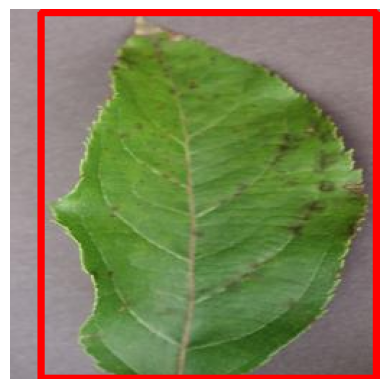

In [ ]:
hybrid_predict("/content/test_leaf.jpeg")


image 1/1 /content/tomato_early_blight.jpeg: 640x480 1 Tomato___Early_blight, 170.2ms
Speed: 3.4ms preprocess, 170.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
🌿 Final Disease: Tomato___Early_blight
📊 Confidence: 0.88
🤖 Source: YOLO
⚠️ Severity: 88.52% (High)
-----


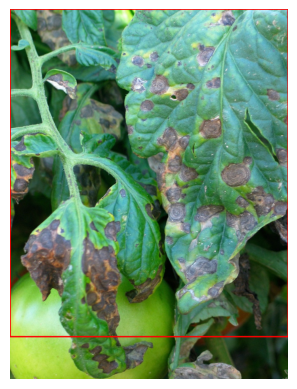

In [ ]:
hybrid_predict("/content/tomato_early_blight.jpeg")


image 1/1 //content/image (1).JPG: 640x640 1 Apple___healthy, 218.0ms
Speed: 5.0ms preprocess, 218.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
🌿 Final Disease: Apple___healthy
📊 Confidence: 0.96
🤖 Source: YOLO
⚠️ Severity: 81.2% (High)
-----


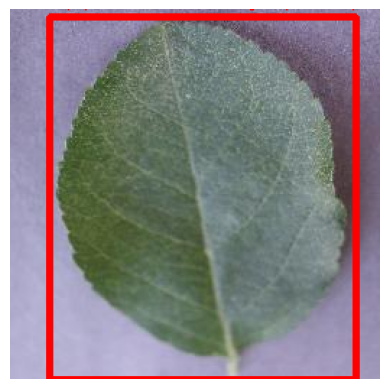

In [ ]:
hybrid_predict("//content/image (1).JPG")